<a href="https://colab.research.google.com/github/Cassio295/Cassio295/blob/master/sales_regression_rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import plotly.express as px
import numpy as np
import kagglehub
path = kagglehub.dataset_download("zahidmughal2343/supplement-sales-data")

In [ ]:
import pathlib
path = pathlib.Path(path)
data = pd.read_csv(path/"Supplement_Sales_Weekly_Expanded.csv")

In [ ]:
data.columns

Index(['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue',
       'Discount', 'Units Returned', 'Location', 'Platform'],
      dtype='object')

In [ ]:
data.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4384 non-null   object 
 1   Product Name    4384 non-null   object 
 2   Category        4384 non-null   object 
 3   Units Sold      4384 non-null   int64  
 4   Price           4384 non-null   float64
 5   Revenue         4384 non-null   float64
 6   Discount        4384 non-null   float64
 7   Units Returned  4384 non-null   int64  
 8   Location        4384 non-null   object 
 9   Platform        4384 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 342.6+ KB


Regressão variavel alvo Revenue


In [ ]:
print(data['Category'].unique(),'\n')
print(data['Product Name'].unique(),'\n')
print(data['Platform'].unique(),'\n')



['Protein' 'Vitamin' 'Omega' 'Performance' 'Amino Acid' 'Mineral' 'Herbal'
 'Sleep Aid' 'Fat Burner' 'Hydration'] 

['Whey Protein' 'Vitamin C' 'Fish Oil' 'Multivitamin' 'Pre-Workout' 'BCAA'
 'Creatine' 'Zinc' 'Collagen Peptides' 'Magnesium' 'Ashwagandha'
 'Melatonin' 'Biotin' 'Green Tea Extract' 'Iron Supplement'
 'Electrolyte Powder'] 

['Walmart' 'Amazon' 'iHerb'] 



In [ ]:
# Transformando a coluna date em datetime
data['Date'] = pd.to_datetime(data['Date'])

# Criando colunas de mes e ano
data['mes'] = data['Date'].dt.month
data['ano'] = data['Date'].dt.year

In [ ]:
data.sort_values(by='Date', inplace=True)
data.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,mes,ano
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,1,2020
15,2020-01-06,Electrolyte Powder,Hydration,154,35.92,5531.68,0.04,2,USA,Amazon,1,2020
14,2020-01-06,Iron Supplement,Mineral,149,42.97,6402.53,0.22,2,Canada,iHerb,1,2020
13,2020-01-06,Green Tea Extract,Fat Burner,143,31.88,4558.84,0.06,3,UK,Walmart,1,2020
12,2020-01-06,Biotin,Vitamin,159,28.79,4577.61,0.10,1,UK,iHerb,1,2020


In [ ]:
# agrupando os dados por produto, localidade, plataforma, ano e mes
data_agrupado = data.groupby(['ano', 'mes', 'Location']).agg({
    "Revenue": "sum",
    "Units Sold": "sum",
    "Units Returned": "sum",

}).reset_index()
# data_agrupado.sort_values(by='Date', inplace=True)
data_agrupado

,ano,mes,Location,Revenue,Units Sold,Units Returned
0,2020,1,Canada,80587.58,2607,22
1,2020,1,UK,112645.85,3273,34
2,2020,1,USA,97490.46,3667,45
3,2020,2,Canada,98534.57,2803,26
4,2020,2,UK,174770.12,4392,45
...,...,...,...,...,...,...
184,2025,2,UK,140984.45,3703,40
185,2025,2,USA,91798.02,2702,28
186,2025,3,Canada,114970.03,4006,48
187,2025,3,UK,142951.72,4719,50


In [ ]:
# Plotando alguns gráficos para entender melhor os dados
fig = px.bar(data_agrupado,
             x='mes',
             y='Revenue',
             color='Platform',
             barmode='group',
             template = 'plotly_dark'
             )
fig.show()

In [ ]:
# Codificando as colunas com o Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data_agrupado['Location'] = le.fit_transform(data_agrupado['Location'])
# data_agrupado['Platform'] = le.fit_transform(data_agrupado['Platform'])

In [ ]:
data_agrupado

,ano,mes,Location,Revenue,Units Sold,Units Returned
0,2020,1,0,80587.58,2607,22
1,2020,1,1,112645.85,3273,34
2,2020,1,2,97490.46,3667,45
3,2020,2,0,98534.57,2803,26
4,2020,2,1,174770.12,4392,45
...,...,...,...,...,...,...
184,2025,2,1,140984.45,3703,40
185,2025,2,2,91798.02,2702,28
186,2025,3,0,114970.03,4006,48
187,2025,3,1,142951.72,4719,50


In [ ]:
teste = data_agrupado.groupby(['Location','ano','mes']).agg({
    'Units Returned': 'sum',
    'Revenue': 'sum',
    'Units Sold': 'sum'
}).reset_index()
teste

,Location,ano,mes,Units Returned,Revenue,Units Sold
0,0,2020,1,22,80587.58,2607
1,0,2020,2,26,98534.57,2803
2,0,2020,3,51,183448.71,4571
3,0,2020,4,29,92410.14,2926
4,0,2020,5,42,153326.84,4411
...,...,...,...,...,...,...
184,2,2024,11,37,92464.65,3011
185,2,2024,12,49,185837.37,5179
186,2,2025,1,27,101565.99,3153
187,2,2025,2,28,91798.02,2702


In [ ]:
teste

,Location,ano,mes,Units Returned,Revenue,Units Sold
0,0,2020,1,22,80587.58,2607
1,0,2020,2,26,98534.57,2803
2,0,2020,3,51,183448.71,4571
3,0,2020,4,29,92410.14,2926
4,0,2020,5,42,153326.84,4411
...,...,...,...,...,...,...
184,2,2024,11,37,92464.65,3011
185,2,2024,12,49,185837.37,5179
186,2,2025,1,27,101565.99,3153
187,2,2025,2,28,91798.02,2702


In [ ]:
# Criando o time step para pegar os últimos 3 meses para fazer a previsão
import numpy as np
X,y = [], []
time_step = 3
for i in range(len(teste) - time_step):
    X.append(teste[i : i+time_step])
    y.append(teste['Revenue'][i + time_step])
X = np.array(X)
y = np.array(y)


# Separação do treino e teste 1


In [ ]:
#UMA FORMA DE DIVIDIR ENTRE TREINO E TESTE
# n_samples, time, n_features = X.shape
# X_reshape = X.reshape(-1, n_features)
# y = y.reshape(-1,1)

# split = int(0.75 * len(X))
# x_train, x_test = X_reshape[:split] , X_reshape[split:]
# y_train, y_test = y[:split], y[split:]

# print(x_train.shape, x_test.shape)
# print(y_train.shape, y_test.shape)

# Separação do treino e teste 2

In [ ]:
# # Testando nova abordagem para sepração dos dados
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import MinMaxScaler
# x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


# # Separandos as informações do x para remoldelar o x no final novamente
# samples_train, time_train, features_train = x_train.shape
# samples_test, time_test, features_test  = x_test.shape


# # Muldando o sahpe para escalonar os dados
# x_train_res = x_train.reshape(-1, features_train)
# x_test_res = x_test.reshape(-1, features_test)

# y_train_res = y_train.reshape(-1,1)
# y_test_res = y_test.reshape(-1,1)

# scaler_x = MinMaxScaler()
# scaler_y = MinMaxScaler()

# # Escalonando os dados
# x_train_scar = scaler_x.fit_transform(x_train_res)
# y_train_scar = scaler_y.fit_transform(y_train_res)


# x_test_scar = scaler_x.transform(x_test_res)
# y_test_scar = scaler_y.transform(y_test_res)

# # Voltando o formato dos dados para poder pegar o time step novamente
# x_train_final = x_train_scar.reshape(samples_train, time_train, features_train)
# x_test_final = x_test_scar.reshape(samples_test, time_test, features_test)

# y_train_final = y_train_scar.flatten()
# y_test_final = y_test_scar.flatten()



# Separação de Treino e Teste 3 a última

Como se trata de dados que usam de seris temporais o contexto é muito importante para o modelo em si, por isso usar técnicas como validation_slit na hora do treinamento não e recomendado por se tratar de uma divisão aleatorio isso pode quebrar a série temporal por isso para os dados de validação e preciso cria-los de forma manual

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Definindo o tamanho do treino, teste e validação
train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.1)
test_size = len(X) - train_size - val_size

x_train, y_train = X[0:train_size], y[0:train_size]
x_val, y_val = X[train_size: train_size + val_size], y[train_size: train_size + val_size]
x_test, y_test = X[train_size + val_size:] , y[train_size + val_size:]

# Pegando as features dos meus dados
train_samples, train_time, train_features = x_train.shape
val_samples, val_time, val_features = x_val.shape
test_samples, test_time, test_features = x_test.shape

# Escalonando meus dados para o treinamento
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

# Dados de treinos
x_train_reshape = x_train.reshape(-1, train_features)
y_train_reshape = y_train.reshape(-1,1)

# dados de validação
x_val_reshape = x_val.reshape(-1,val_features)
y_val_reshape = y_val.reshape(-1,1)

# dados de teste
x_test_reshape = x_test.reshape(-1, test_features)
y_test_reshape = y_test.reshape(-1,1)

# Escalonando dados de treino
x_train_scalar = scaler_x.fit_transform(x_train_reshape)
y_train_scaler = scaler_y.fit_transform(y_train_reshape)

# Escalando Dados de teste
x_test_scalar = scaler_x.transform(x_test_reshape)
y_test_scaler = scaler_y.transform(y_test_reshape)

# Escalando dados de Validação
x_val_scaler = scaler_x.transform(x_val_reshape)
y_val_scaler = scaler_y.transform(y_val_reshape)


# Remodelando novamente os dados para treinar as RNNs
x_train_final = x_train_scalar.reshape(train_samples, train_time, train_features)
y_train_final = y_train_scaler.flatten()

x_test_final = x_test_scalar.reshape(test_samples, test_time, test_features)
y_test_final = y_test_scaler.flatten()

x_val_final = x_val_scaler.reshape(val_samples, val_time, val_features)
y_val_final = y_val_scaler.flatten()


## Começando a construir as arquiteturas da rede

In [ ]:
x_train_final.shape

(148, 3, 6)

Epoch 1/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - RootMeanSquaredError: 0.3498 - loss: 0.4092 - mae: 0.2927 - val_RootMeanSquaredError: 0.3102 - val_loss: 0.3828 - val_mae: 0.2720 - learning_rate: 5.0000e-05
Epoch 2/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - RootMeanSquaredError: 0.3514 - loss: 0.4101 - mae: 0.2929 - val_RootMeanSquaredError: 0.2950 - val_loss: 0.3734 - val_mae: 0.2559 - learning_rate: 5.0000e-05
Epoch 3/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - RootMeanSquaredError: 0.3412 - loss: 0.4028 - mae: 0.2798 - val_RootMeanSquaredError: 0.2841 - val_loss: 0.3670 - val_mae: 0.2442 - learning_rate: 5.0000e-05
Epoch 4/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - RootMeanSquaredError: 0.3216 - loss: 0.3897 - mae: 0.2591 - val_RootMeanSquaredError: 0.2739 - val_loss: 0.3611 - val_mae: 0.2331 - learning_rate: 5.0000e-05
Epoch 5/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - RootMeanSquaredError: 0.3204 - loss: 0.3887 - mae: 0.2637 - val_RootMeanSquaredError: 0.2662 - val_loss: 0

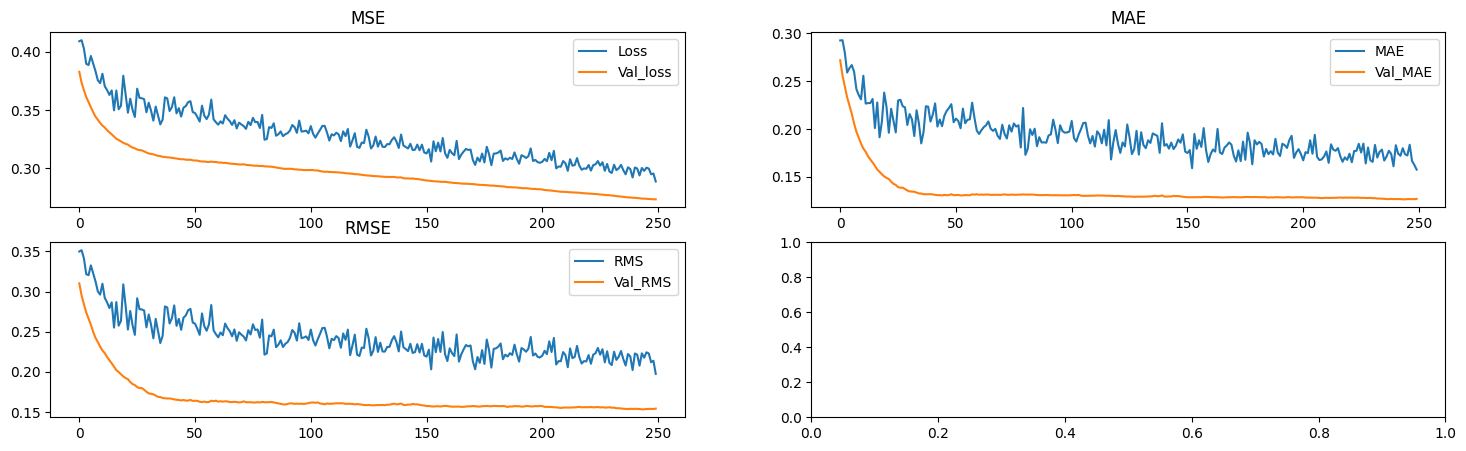

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, SimpleRNN, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras import optimizers
import matplotlib.pyplot as plt

early = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights= True
)

lear = ReduceLROnPlateau(monitor = 'val_loss', verbose = 1, factor = 0.001, min_lr = 0.0001)


model_simple = Sequential()
model_simple.add(Input(shape = (3,6)))

model_simple.add(SimpleRNN(units=128, activation = 'relu', return_sequences=True, kernel_regularizer=l2(0.003)))
model_simple.add(Dropout(0.3))

model_simple.add(SimpleRNN(units = 64, activation = 'relu', return_sequences=False, kernel_regularizer=l2(0.003)))
model_simple.add(Dropout(0.3))
model_simple.add(Dense(1))

model_simple.compile(optimizer=optimizers.RMSprop(learning_rate = 0.00005), loss = 'mse', metrics=['mae','RootMeanSquaredError'])
model_simple.fit(x_train_final, y_train_final, batch_size=258, epochs=250, validation_data=(x_val_final, y_val_final), callbacks= [early, lear])



fig, ax = plt.subplots(2,2, figsize=(18,5))
# Plotando curva da função de perda Mean Absolute Error
ax[0][0].plot(model_simple.history.history['loss'], label = 'Loss')
ax[0][0].plot(model_simple.history.history['val_loss'], label = 'Val_loss')
ax[0][0].set_title('MSE')
ax[0][0].legend()

# Curva de Mean Squared Error
ax[0][1].plot(model_simple.history.history['mae'], label = 'MAE')
ax[0][1].plot(model_simple.history.history['val_mae'], label = 'Val_MAE')
ax[0][1].set_title('MAE')
ax[0][1].legend()

# Curva RootMeanSquaredError
ax[1][0].plot(model_simple.history.history['RootMeanSquaredError'], label = 'RMS')
ax[1][0].plot(model_simple.history.history['val_RootMeanSquaredError'], label = 'Val_RMS')
ax[1][0].set_title('RMSE')
ax[1][0].legend()

# Curva Mape
# ax[1][1].plot(model_simple.history.history['mape'], label ='mape')
# ax[1][1].plot(model_simple.history.history['val_mape'], label ='val_mape')
# ax[1][1].set_title('MAPE')
# ax[1][1].legend()

fig.show()


Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 603ms/step - RootMeanSquaredError: 1.6270 - loss: 2.9373 - mae: 1.2994 - val_RootMeanSquaredError: 0.3178 - val_loss: 0.3876 - val_mae: 0.2850 - learning_rate: 0.0010
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - RootMeanSquaredError: 1.2611 - loss: 1.8771 - mae: 1.0307 - val_RootMeanSquaredError: 0.2984 - val_loss: 0.3722 - val_mae: 0.2632 - learning_rate: 0.0010
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - RootMeanSquaredError: 1.2401 - loss: 1.8210 - mae: 0.9518 - val_RootMeanSquaredError: 0.2838 - val_loss: 0.3608 - val_mae: 0.2466 - learning_rate: 0.0010
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - RootMeanSquaredError: 1.1206 - loss: 1.5360 - mae: 0.8876 - val_RootMeanSquaredError: 0.2730 - val_loss: 0.3522 - val_mae: 0.2353 - learning_rate: 0.0010
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - RootMeanSquaredError: 1.1123 - loss: 1.5149 - mae: 0.8803 - val_RootMeanSquaredError: 0.2606 - val_loss: 0.3430 - val_mae:

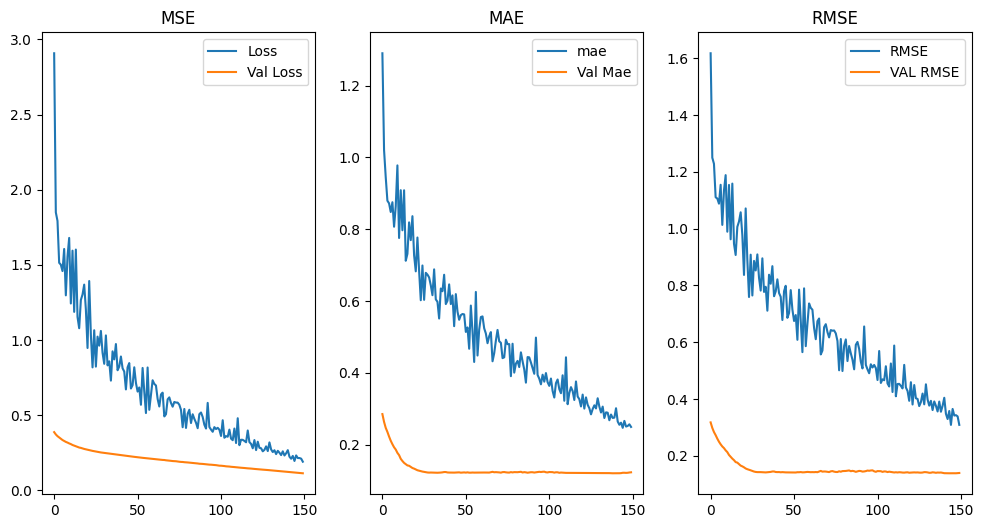

In [ ]:
# Testando o uso de uma LSTM para comparar os valores
from tensorflow.keras.layers import LSTM
from tensorflow.keras.regularizers import l2, l1
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow import optimizers


model_lstm = Sequential()
model_lstm.add(Input(shape = (3,6)))

model_lstm.add(LSTM(64, return_sequences=True, activation='relu',kernel_regularizer=l2(0.003)))
model_lstm.add(Dropout(0.3))
model_lstm.add(BatchNormalization())

# model_lstm.add(LSTM(64, return_sequences=True, activation='relu',kernel_regularizer=l2(0.003)))
# model_lstm.add(Dropout(0.3))
# model_lstm.add(BatchNormalization())

model_lstm.add(LSTM(32, return_sequences=False, activation='relu',kernel_regularizer=l2(0.003)))
model_lstm.add(Dropout(0.3))
model_lstm.add(BatchNormalization())

model_lstm.add(Dense(1))



early = EarlyStopping(
    monitor = 'val_loss',
    patience = 15,
    restore_best_weights=True
)

lear = ReduceLROnPlateau(
      monitor='val_loss',    # Monitorar a perda de validação
      factor=0.5,            # Reduz o learning rate pela metade
      patience=10,            # Espera 5 épocas sem melhora para reduzir
      min_lr=1e-6,           # Não deixa o learning rate ficar menor que 0.000001
      verbose=1)

model_lstm.compile(optimizer = 'rmsprop', loss='mse', metrics=['mae', 'RootMeanSquaredError'])

model_lstm.fit(x_train_final, y_train_final, epochs = 150, batch_size=128, validation_data = (x_val_final, y_val_final), callbacks= [lear, early])


fig, ax = plt.subplots(1,3, figsize = (12,6))
ax[0].plot(model_lstm.history.history['loss'], label = 'Loss')
ax[0].plot(model_lstm.history.history['val_loss'], label = 'Val Loss')

ax[1].plot(model_lstm.history.history['mae'], label = 'mae')
ax[1].plot(model_lstm.history.history['val_mae'], label = 'Val Mae')

ax[2].plot(model_lstm.history.history['RootMeanSquaredError'], label = 'RMSE')
ax[2].plot(model_lstm.history.history['val_RootMeanSquaredError'], label = 'VAL RMSE')



ax[0].set_title('MSE')
ax[1].set_title('MAE')
ax[2].set_title('RMSE')



ax[0].legend()
ax[1].legend()
ax[2].legend()

fig.show()

Fazendo previsões com os modelos

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 308ms/step - RootMeanSquaredError: 0.4609 - loss: 0.6854 - mse: 0.2124 - val_RootMeanSquaredError: 0.4090 - val_loss: 0.6487 - val_mse: 0.1673 - learning_rate: 6.0000e-05
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - RootMeanSquaredError: 0.4384 - loss: 0.6573 - mse: 0.1922 - val_RootMeanSquaredError: 0.3873 - val_loss: 0.6248 - val_mse: 0.1500 - learning_rate: 6.0000e-05
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - RootMeanSquaredError: 0.4266 - loss: 0.6441 - mse: 0.1821 - val_RootMeanSquaredError: 0.3691 - val_loss: 0.6046 - val_mse: 0.1363 - learning_rate: 6.0000e-05
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - RootMeanSquaredError: 0.4027 - loss: 0.6204 - mse: 0.1622 - val_RootMeanSquaredError: 0.3538 - val_loss: 0.5873 - val_mse: 0.1252 - learning_rate: 6.0000e-05
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - RootMeanSquaredError: 0.3886 - loss: 0.6010 - mse: 0.1511 - val_RootMeanSquaredError: 0.3393 - val_loss: 0.

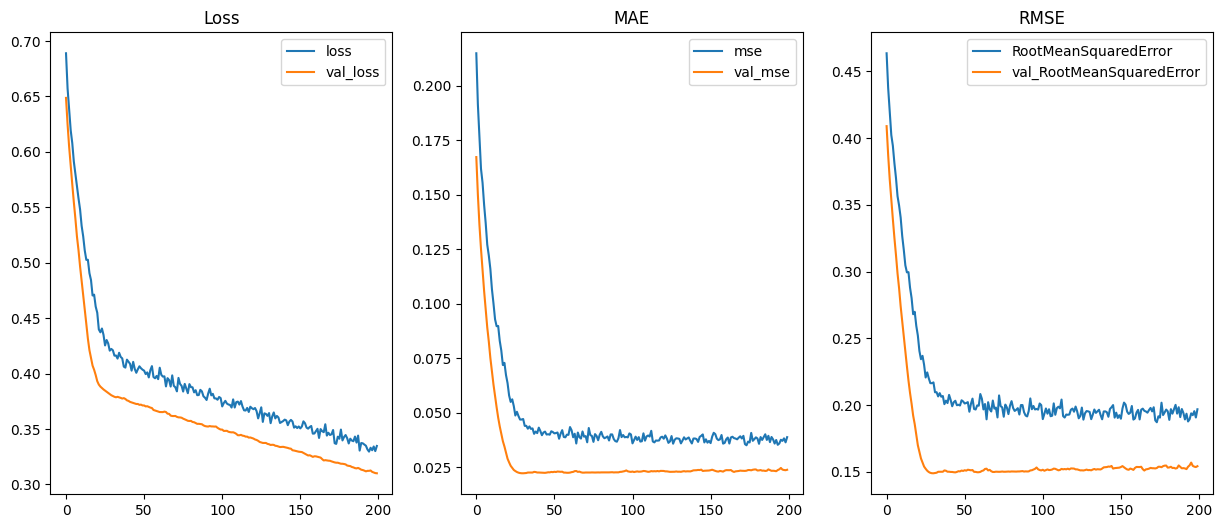

In [ ]:
from tensorflow.keras.layers import GRU, LeakyReLU


model_gru = Sequential()

model_gru.add(Input(shape = (3,6)))
model_gru.add(GRU(64, activation='tanh', return_sequences = True,  kernel_regularizer=l2(0.003)))
model_gru.add(GRU(32, activation='tanh', return_sequences = False,  kernel_regularizer=l2(0.003)))
model_gru.add(Dropout(0.2))

model_gru.add(Dense(1, activation = 'linear'))

model_gru.compile(optimizer= optimizers.RMSprop(learning_rate=0.00006), loss = 'mae', metrics=['mse', 'RootMeanSquaredError'])

model_gru.fit(x_train_final, y_train_final, batch_size= 64, epochs=200, validation_data=(x_val_final, y_val_final), callbacks = [lear, early])

fig, ax = plt.subplots(1,3, figsize = (15,6))
ax[0].plot(model_gru.history.history ['loss'], label = 'loss')
ax[0].plot(model_gru.history.history['val_loss'], label = 'val_loss')

ax[1].plot(model_gru.history.history['mse'], label = 'mse')
ax[1].plot(model_gru.history.history['val_mse'], label = 'val_mse')

ax[2].plot(model_gru.history.history['RootMeanSquaredError'], label = 'RootMeanSquaredError')
ax[2].plot(model_gru.history.history['val_RootMeanSquaredError'], label = 'val_RootMeanSquaredError')

ax[0].set_title('Loss')
ax[1].set_title('MAE')
ax[2].set_title('RMSE')

ax[0].legend()
ax[1].legend()
ax[2].legend()




fig.show()



In [ ]:
# Fazendo as previsões
y_pred_simple = model_simple.predict(x_test_final)
y_pred_lstm = model_lstm.predict(x_test_final)
y_pred_gru = model_gru.predict(x_test_final)

# Revertendo o escalonamento das previsões
y_pred_gru_final = scaler_y.inverse_transform(y_pred_gru.reshape(-1,1)).flatten()
y_pred_lstm_final = scaler_y.inverse_transform(y_pred_lstm.reshape(-1,1)).flatten()
y_pred_simple_final = scaler_y.inverse_transform(y_pred_simple.reshape(-1,1)).flatten()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step


In [ ]:
results = {
    'SimpleRNN': y_pred_simple_final,
    'LSTM': y_pred_lstm_final,
    'GRU':  y_pred_gru_final,
    'Dados reais': y_test
}

results

{'SimpleRNN': array([116099.73 , 111793.9  , 109931.24 , 113507.26 , 119264.63 ,
        118047.58 , 111180.21 , 131777.44 , 113653.72 , 117830.516,
        120193.766, 116266.22 , 113236.58 , 113336.695, 109223.67 ,
        121306.14 , 120951.05 , 119628.07 , 115220.39 , 127166.73 ],
       dtype=float32),
 'LSTM': array([120638.94 , 120419.86 , 120178.96 , 119859.88 , 119526.09 ,
        119527.68 , 120597.94 , 121836.664, 122498.94 , 122878.46 ,
        122835.68 , 122665.6  , 121242.695, 121636.71 , 122177.5  ,
        122273.664, 121750.4  , 121473.555, 122352.9  , 123284.484],
       dtype=float32),
 'GRU': array([118496.71, 118118.91, 117619.39, 119055.72, 122313.46, 120291.41,
        110553.37, 110494.51, 113245.22, 110056.24, 113972.53, 117749.98,
        117820.64, 116383.77, 113450.6 , 119231.52, 120759.79, 115940.61,
        112997.07, 113445.11], dtype=float32),
 'Dados reais': array([ 98078.83, 116673.01, 110499.49,  94772.86, 123529.5 , 137598.54,
        116940.85,  95